# 09_v2 - Team Classification on Hierarchical Tracker

## Objective

Assign each player track to one of the two teams using mainly jersey appearance.

The classification is performed at track level rather than frame level,
so that multiple observations of the same player can be exploited to reduce
the effect of:

- illumination changes;
- motion blur;
- occlusions;
- pose variations.

Pipeline:

Hierarchical tracking players-only
→ player crop
→ torso crop
→ color features
→ temporal aggregation per track
→ clustering
→ team label

Referee tracks have already been removed in Notebook 03.

In [3]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
from pathlib import Path

DRIVE_ROOT = Path(
    "/Users/marcodalbis/Library/CloudStorage/"
    "GoogleDrive-marco.dalbis@gmail.com/"
    "Il mio Drive/"
    "basketball-thesis"
)

SEQUENCE_NAME = "v_00HRwkvvjtQ_c001"

FRAMES_DIR = (
    DRIVE_ROOT
    / "datasets"
    / "sportsmot"
    / "val"
    / SEQUENCE_NAME
    / "img1"
)

TRACKS_CSV = (
    DRIVE_ROOT
    / "experiments"
    / "hierarchical_tracking"
    / f"{SEQUENCE_NAME}_hierarchical_players_only.csv"
)

OUTPUT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "hierarchical_tracking"
    / "team_classification"
    / SEQUENCE_NAME
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Frames:", FRAMES_DIR.exists())
print("Tracks:", TRACKS_CSV.exists())
print("Output:", OUTPUT_DIR)

assert FRAMES_DIR.exists(), FRAMES_DIR
assert TRACKS_CSV.exists(), TRACKS_CSV

Frames: True
Tracks: True
Output: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking/team_classification/v_00HRwkvvjtQ_c001


Caricamento Tracking

In [5]:
if torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.14.0
Device: mps


In [7]:
# ============================================================
# LOAD PLAYER-ONLY TRACKS
# ============================================================

tracks_df = pd.read_csv(
    TRACKS_CSV
)

print("Loaded tracks:")
print("Rows:", len(tracks_df))
print("Unique track IDs:", tracks_df["track_id"].nunique())

print("\nColumns:")
print(tracks_df.columns.tolist())

display(
    tracks_df.head()
)

Loaded tracks:
Rows: 11318
Unique track IDs: 95

Columns:
['frame', 'track_id', 'x1', 'y1', 'x2', 'y2', 'width', 'height', 'confidence', 'confirmed']


,frame,track_id,x1,y1,x2,y2,width,height,confidence,confirmed
0,1,0,439.375305,266.329010,558.552917,436.577148,119.177612,170.248138,0.938461,False
1,1,1,971.564453,389.879883,1049.835327,605.411072,78.270874,215.531189,0.915086,False
2,1,2,637.455872,419.139099,764.137878,627.321350,126.682007,208.182251,0.870535,False
3,1,3,990.353394,290.022308,1052.396118,495.324768,62.042725,205.302460,0.847963,False
4,1,4,644.804443,272.780945,756.591858,430.809967,111.787415,158.029022,0.823956,False


In [8]:
print(
    tracks_df.columns.tolist()
)

['frame', 'track_id', 'x1', 'y1', 'x2', 'y2', 'width', 'height', 'confidence', 'confirmed']


Distribuzione Colonne Track

In [9]:
track_counts = (
    tracks_df["track_id"]
    .value_counts()
    .sort_values(
        ascending=False
    )
)

display(
    track_counts.to_frame(
        "observations"
    )
)

print(
    "Median track length:",
    track_counts.median()
)

,observations
track_id,
4,1156
35,882
10,812
28,802
65,518
...,...
33,1
27,1
26,1


Median track length: 8.0


## Estrazione dei player crop

Per ogni bounding box del tracker viene estratta l'immagine del giocatore.

Per la classificazione della squadra verrà utilizzata principalmente la
regione superiore del corpo, poiché contiene la parte più informativa
della divisa e riduce l'influenza di parquet, scarpe e sfondo.

Funzione player Crop

In [10]:
def extract_player_crop(
    frame,
    x1,
    y1,
    x2,
    y2,
):

    h, w = frame.shape[:2]

    x1 = max(
        0,
        int(round(x1))
    )

    y1 = max(
        0,
        int(round(y1))
    )

    x2 = min(
        w,
        int(round(x2))
    )

    y2 = min(
        h,
        int(round(y2))
    )

    if x2 <= x1 or y2 <= y1:
        return None

    crop = frame[
        y1:y2,
        x1:x2
    ]

    return crop

Regione Torso

In [11]:
def extract_torso(player_crop):

    if player_crop is None:
        return None

    h, w = player_crop.shape[:2]

    if h < 20 or w < 10:
        return None

    y1 = int(0.18 * h)
    y2 = int(0.52 * h)

    x1 = int(0.25 * w)
    x2 = int(0.75 * w)

    torso = player_crop[
        y1:y2,
        x1:x2
    ]

    if torso.size == 0:
        return None

    return torso

Selezione Track Lungo

In [12]:
TEST_TRACK_ID = int(
    track_counts.index[0]
)

test_track = (
    tracks_df[
        tracks_df["track_id"]
        == TEST_TRACK_ID
    ]
    .sort_values("frame")
)

sample_row = (
    test_track
    .iloc[
        len(test_track) // 2
    ]
)

print(
    "Track ID:",
    TEST_TRACK_ID
)

display(
    sample_row.to_frame(
        "value"
    )
)

Track ID: 4


,value
frame,585
track_id,4
x1,566.973022
y1,131.55394
x2,632.687622
y2,264.126831
width,65.7146
height,132.572891
confidence,0.816116
confirmed,True


Visualizzazione player e torso

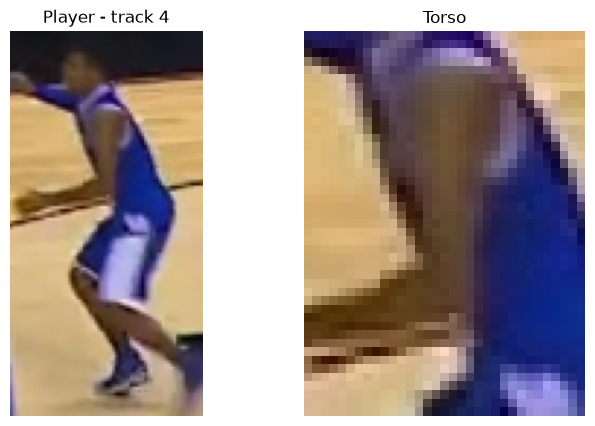

In [13]:
frame_number = int(
    sample_row["frame"]
)

frame_path = (
    FRAMES_DIR
    / f"{frame_number:06d}.jpg"
)

frame = cv2.imread(
    str(frame_path)
)

assert frame is not None

player_crop = extract_player_crop(
    frame,
    sample_row["x1"],
    sample_row["y1"],
    sample_row["x2"],
    sample_row["y2"],
)

torso_crop = extract_torso(
    player_crop
)

plt.figure(
    figsize=(8, 5)
)

plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    cv2.cvtColor(
        player_crop,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Player - track {TEST_TRACK_ID}"
)

plt.axis("off")

plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    cv2.cvtColor(
        torso_crop,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Torso")

plt.axis("off")

plt.show()

Feature Colore

In [14]:
def color_features(torso):

    if torso is None or torso.size == 0:
        return None

    hsv = cv2.cvtColor(
        torso,
        cv2.COLOR_BGR2HSV
    )

    lab = cv2.cvtColor(
        torso,
        cv2.COLOR_BGR2LAB
    )

    hsv_pixels = hsv.reshape(-1, 3)
    lab_pixels = lab.reshape(-1, 3)

    H = hsv_pixels[:, 0]
    S = hsv_pixels[:, 1]
    V = hsv_pixels[:, 2]

    L = lab_pixels[:, 0]

    # Statistiche robuste
    hsv_median = np.median(
        hsv_pixels,
        axis=0
    )

    lab_median = np.median(
        lab_pixels,
        axis=0
    )

    hsv_q25 = np.percentile(
        hsv_pixels,
        25,
        axis=0
    )

    hsv_q75 = np.percentile(
        hsv_pixels,
        75,
        axis=0
    )

    # Feature aggiuntive per maglie chiare/scure
    white_ratio = np.mean(
        (S < 60)
        & (V > 150)
    )

    bright_ratio = np.mean(
        V > 170
    )

    dark_ratio = np.mean(
        V < 90
    )

    low_saturation_ratio = np.mean(
        S < 70
    )

    mean_saturation = np.mean(S)
    mean_value = np.mean(V)
    mean_lightness = np.mean(L)

    features = np.concatenate([
        hsv_median,
        lab_median,
        hsv_q25,
        hsv_q75,
        [
            white_ratio,
            bright_ratio,
            dark_ratio,
            low_saturation_ratio,
            mean_saturation,
            mean_value,
            mean_lightness,
        ]
    ])

    return features.astype(
        np.float32
    )

Campionamento Temporale

In [15]:
MAX_SAMPLES_PER_TRACK = 25

MIN_BOX_HEIGHT = 60
MIN_BOX_WIDTH = 20

MIN_CONFIDENCE = 0.50

Estrazione Feature da tutti i track

In [16]:
feature_rows = []

unique_tracks = sorted(
    tracks_df["track_id"].unique()
)

for track_id in unique_tracks:

    track_data = (
        tracks_df[
            tracks_df["track_id"]
            == track_id
        ]
        .sort_values("frame")
        .copy()
    )

    if len(track_data) == 0:
        continue

    if len(track_data) > MAX_SAMPLES_PER_TRACK:

        indices = np.linspace(
            0,
            len(track_data) - 1,
            MAX_SAMPLES_PER_TRACK
        ).astype(int)

        track_data = (
            track_data
            .iloc[indices]
        )

    for _, row in track_data.iterrows():

        if row["confidence"] < MIN_CONFIDENCE:
            continue

        box_width = (
            row["x2"]
            - row["x1"]
        )

        box_height = (
            row["y2"]
            - row["y1"]
        )

        if box_width < MIN_BOX_WIDTH:
            continue

        if box_height < MIN_BOX_HEIGHT:
            continue

        frame_number = int(
            row["frame"]
        )

        frame_path = (
            FRAMES_DIR
            / f"{frame_number:06d}.jpg"
        )

        frame = cv2.imread(
            str(frame_path)
        )

        if frame is None:
            continue

        player_crop = extract_player_crop(
            frame,
            row["x1"],
            row["y1"],
            row["x2"],
            row["y2"],
        )

        torso = extract_torso(
            player_crop
        )

        features = color_features(
            torso
        )

        if features is None:
            continue

        feature_rows.append({
            "track_id": int(track_id),
            "frame": frame_number,
            **{
                f"f{i}": float(value)
                for i, value
                in enumerate(features)
            }
        })

feature_df = pd.DataFrame(
    feature_rows
)

print(
    "Feature observations:",
    len(feature_df)
)

print(
    "Tracks represented:",
    feature_df["track_id"].nunique()
)

display(
    feature_df.head()
)

Feature observations: 1053
Tracks represented: 66


,track_id,frame,f0,f1,f2,f3,f4,f5,f6,f7,...,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18
0,0,1,132.0,58.0,169.0,156.0,141.0,122.0,16.0,44.0,...,147.0,105.0,213.0,0.422989,0.492529,0.209195,0.608333,81.654594,160.609192,140.738220
1,0,8,128.0,67.0,190.0,169.0,140.0,126.0,17.0,47.0,...,141.0,121.0,213.0,0.370236,0.600121,0.138536,0.508772,88.195702,170.674225,149.588928
2,0,15,135.0,51.0,188.0,171.0,141.0,117.0,128.0,42.0,...,149.0,66.0,217.0,0.592504,0.640750,0.085726,0.766746,61.701355,179.760361,159.602478
3,0,23,133.0,51.0,185.0,170.0,141.0,121.0,16.0,43.0,...,145.0,88.0,219.0,0.555714,0.618095,0.114762,0.695714,70.514282,176.372375,155.772858
4,0,30,132.0,58.0,184.0,167.0,141.0,126.0,17.0,45.0,...,154.0,122.0,213.0,0.426441,0.603051,0.055932,0.559322,84.363388,175.110504,154.503052


Aggregazione Frame

In [17]:
feature_columns = [
    column
    for column in feature_df.columns
    if column.startswith("f")
]

track_features = (
    feature_df
    .groupby("track_id")[
        feature_columns
    ]
    .median()
)

track_features[
    "num_samples"
] = (
    feature_df
    .groupby("track_id")
    .size()
)

Filtra Track poco rappresentativi

In [18]:
MIN_FEATURE_SAMPLES = 3

valid_track_features = (
    track_features[
        track_features["num_samples"]
        >= MIN_FEATURE_SAMPLES
    ]
    .copy()
)

print(
    "Tracks used for clustering:",
    len(valid_track_features)
)

Tracks used for clustering: 54


## Clusteriong

Standardizzazione

In [19]:
# Referees were already removed in Notebook 03.
# Therefore every valid track entering this notebook is treated as a player track.

player_track_features = (
    valid_track_features
    .copy()
)

print(
    "Valid player tracks:",
    len(player_track_features)
)

Valid player tracks: 54


In [20]:
X = (
    player_track_features[
        feature_columns
    ]
    .values
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

print(
    X_scaled.shape
)

(54, 20)


K-means

In [21]:
N_CLUSTERS = 2

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=50,
)

cluster_labels = kmeans.fit_predict(
    X_scaled
)

player_track_features[
    "cluster"
] = cluster_labels

display(
    player_track_features[
        ["num_samples", "cluster"]
    ]
    .sort_values(
        "cluster"
    )
)

,num_samples,cluster
track_id,,
0,24,0
50,3,0
48,24,0
46,25,0
45,24,0
44,23,0
101,25,0
41,4,0
32,8,0


In [22]:
track_vote_rows = []

for _, row in feature_df.iterrows():

    track_id = int(row["track_id"])

    if track_id not in player_track_features.index:
        continue

    features = (
        row[feature_columns]
        .values
        .astype(float)
        .reshape(1, -1)
    )

    features_scaled = scaler.transform(
        features
    )

    frame_cluster = int(
        kmeans.predict(
            features_scaled
        )[0]
    )

    track_vote_rows.append({
        "track_id": track_id,
        "frame": int(row["frame"]),
        "frame_cluster": frame_cluster,
    })

frame_votes_df = pd.DataFrame(
    track_vote_rows
)

display(
    frame_votes_df.head()
)

,track_id,frame,frame_cluster
0,0,1,0
1,0,8,0
2,0,15,0
3,0,23,0
4,0,30,0


In [23]:
track_ids_to_check = (
    player_track_features
    .sort_values(
        "num_samples",
        ascending=False
    )
    .head(5)
    .index
    .tolist()
)

print(
    "Track da controllare:",
    track_ids_to_check
)

for track_id in track_ids_to_check:

    votes = (
        frame_votes_df[
            frame_votes_df["track_id"] == track_id
        ]["frame_cluster"]
        .value_counts()
        .sort_index()
    )

    print(
        f"\nTrack {track_id}"
    )

    print(votes)

Track da controllare: [10, 65, 101, 94, 7]

Track 10
frame_cluster
0    24
1     1
Name: count, dtype: int64

Track 65
frame_cluster
0     1
1    24
Name: count, dtype: int64

Track 101
frame_cluster
0    25
Name: count, dtype: int64

Track 94
frame_cluster
0     4
1    21
Name: count, dtype: int64

Track 7
frame_cluster
0     9
1    16
Name: count, dtype: int64


In [24]:
track_team_consistency = (
    frame_votes_df
    .groupby(
        [
            "track_id",
            "frame_cluster"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

for cluster_id in [0, 1]:

    if cluster_id not in track_team_consistency.columns:
        track_team_consistency[
            cluster_id
        ] = 0

track_team_consistency[
    "total"
] = (
    track_team_consistency[
        [0, 1]
    ]
    .sum(
        axis=1
    )
)

track_team_consistency[
    "ratio_cluster_0"
] = (
    track_team_consistency[0]
    / track_team_consistency["total"]
)

track_team_consistency[
    "ratio_cluster_1"
] = (
    track_team_consistency[1]
    / track_team_consistency["total"]
)

track_team_consistency[
    "max_team_ratio"
] = (
    track_team_consistency[
        [
            "ratio_cluster_0",
            "ratio_cluster_1"
        ]
    ]
    .max(
        axis=1
    )
)

track_team_consistency[
    "ambiguous"
] = (
    track_team_consistency[
        "max_team_ratio"
    ]
    < 0.80
)

display(
    track_team_consistency.sort_values(
        "max_team_ratio"
    )
)

frame_cluster,0,1,total,ratio_cluster_0,ratio_cluster_1,max_team_ratio,ambiguous
track_id,,,,,,,
73,7,7,14,0.500000,0.500000,0.500000,True
13,6,8,14,0.428571,0.571429,0.571429,True
1,14,10,24,0.583333,0.416667,0.583333,True
78,10,14,24,0.416667,0.583333,0.583333,True
7,9,16,25,0.360000,0.640000,0.640000,True
42,6,11,17,0.352941,0.647059,0.647059,True
79,15,8,23,0.652174,0.347826,0.652174,True
51,8,15,23,0.347826,0.652174,0.652174,True
54,1,2,3,0.333333,0.666667,0.666667,True


In [25]:
AMBIGUOUS_THRESHOLD = 0.80

ambiguous_tracks = (
    track_team_consistency[
        track_team_consistency[
            "max_team_ratio"
        ]
        < AMBIGUOUS_THRESHOLD
    ]
    .index
    .tolist()
)

print(
    "Ambiguous tracks:",
    ambiguous_tracks
)

Ambiguous tracks: [0, 1, 7, 9, 12, 13, 32, 36, 42, 51, 52, 54, 55, 67, 73, 78, 79]


## Visualizzazione PCA
Serve solo a capire se i gruppi sono effettivamente separabili.
### PCA

In [26]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({
    "track_id": player_track_features.index,
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    "cluster": cluster_labels,
})

display(
    pca_df
)

,track_id,pc1,pc2,cluster
0,0,2.417746,-0.341793,0
1,1,0.837461,0.034841,0
2,2,4.047537,-0.070862,0
3,3,-4.945301,0.641846,1
4,4,-4.228105,0.406232,1
5,6,-0.189679,-6.441979,1
6,7,-2.215559,-0.222449,1
7,8,-3.388591,-0.598899,1
8,9,1.439987,0.091735,0
9,10,3.241898,-0.154263,0


### Grafico Cluster

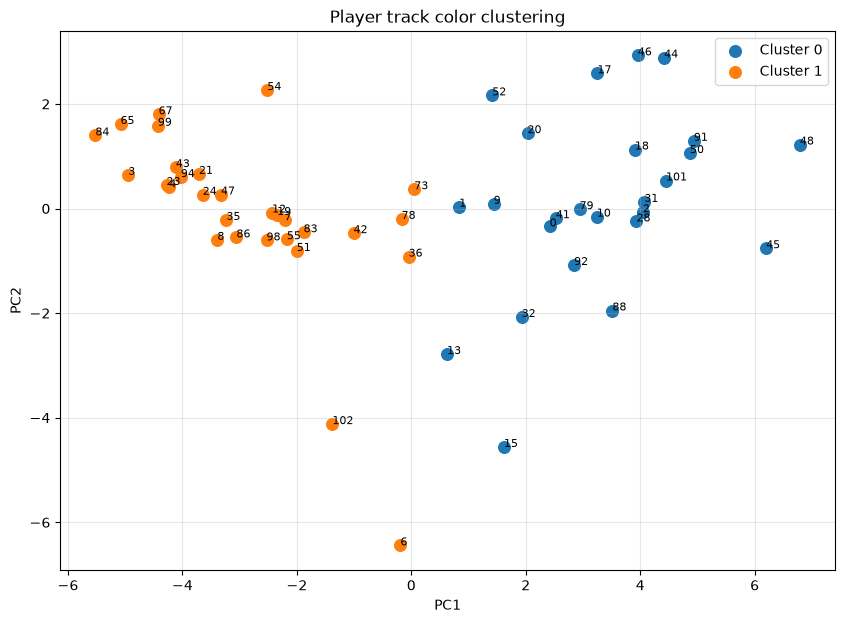

In [27]:
plt.figure(
    figsize=(10, 7)
)

for cluster_id in sorted(
    pca_df["cluster"].unique()
):

    subset = (
        pca_df[
            pca_df["cluster"]
            == cluster_id
        ]
    )

    plt.scatter(
        subset["pc1"],
        subset["pc2"],
        label=f"Cluster {cluster_id}",
        s=70,
    )

for _, row in pca_df.iterrows():

    plt.text(
        row["pc1"],
        row["pc2"],
        str(
            int(
                row["track_id"]
            )
        ),
        fontsize=8,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Player track color clustering"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

Funzione representative crop

In [28]:
def get_representative_crop(
    track_id
):

    rows = (
        tracks_df[
            tracks_df["track_id"]
            == track_id
        ]
        .sort_values(
            "confidence",
            ascending=False
        )
    )

    for _, row in rows.iterrows():

        frame_number = int(
            row["frame"]
        )

        frame_path = (
            FRAMES_DIR
            / f"{frame_number:06d}.jpg"
        )

        frame = cv2.imread(
            str(frame_path)
        )

        if frame is None:
            continue

        crop = extract_player_crop(
            frame,
            row["x1"],
            row["y1"],
            row["x2"],
            row["y2"],
        )

        if crop is not None:
            return crop

    return None

Galleria di tutti i Track

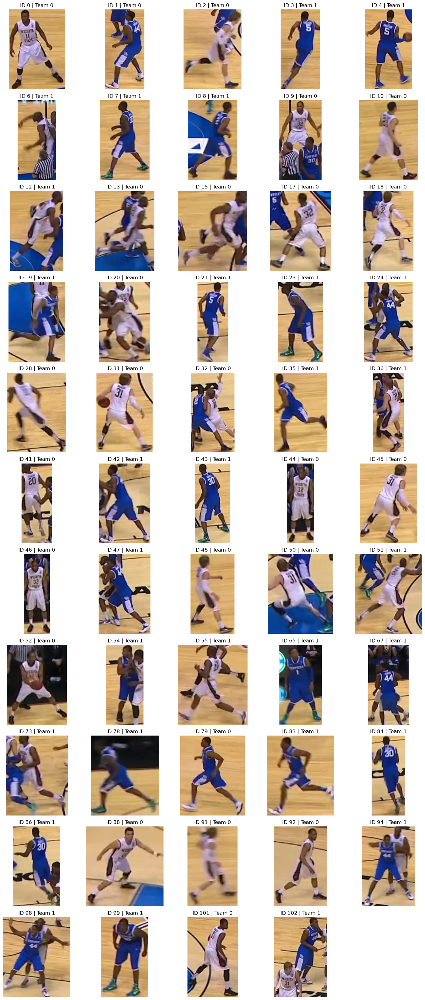

In [29]:
cluster_table = (
    player_track_features[
        ["cluster"]
    ]
    .reset_index()
)

n_tracks = len(
    cluster_table
)

cols = 5

rows = int(
    np.ceil(
        n_tracks / cols
    )
)

plt.figure(
    figsize=(
        15,
        rows * 3
    )
)

for i, row in cluster_table.iterrows():

    track_id = int(
        row["track_id"]
    )

    cluster_id = int(
        row["cluster"]
    )

    crop = get_representative_crop(
        track_id
    )

    ax = plt.subplot(
        rows,
        cols,
        i + 1
    )

    if crop is not None:

        ax.imshow(
            cv2.cvtColor(
                crop,
                cv2.COLOR_BGR2RGB
            )
        )

    ax.set_title(
        f"ID {track_id} | Team {cluster_id}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [30]:
def show_track_samples(
    track_id,
    n_samples=12
):

    track_data = (
        tracks_df[
            tracks_df["track_id"] == track_id
        ]
        .sort_values("frame")
        .copy()
    )

    if len(track_data) == 0:
        print("Track non trovato:", track_id)
        return

    indices = np.linspace(
        0,
        len(track_data) - 1,
        min(n_samples, len(track_data))
    ).astype(int)

    samples = track_data.iloc[
        indices
    ]

    cols = 4
    rows = int(
        np.ceil(
            len(samples) / cols
        )
    )

    plt.figure(
        figsize=(
            12,
            rows * 4
        )
    )

    for i, (_, row) in enumerate(
        samples.iterrows()
    ):

        frame_number = int(
            row["frame"]
        )

        frame_path = (
            FRAMES_DIR
            / f"{frame_number:06d}.jpg"
        )

        frame = cv2.imread(
            str(frame_path)
        )

        if frame is None:
            continue

        crop = extract_player_crop(
            frame,
            row["x1"],
            row["y1"],
            row["x2"],
            row["y2"],
        )

        ax = plt.subplot(
            rows,
            cols,
            i + 1
        )

        if crop is not None:

            ax.imshow(
                cv2.cvtColor(
                    crop,
                    cv2.COLOR_BGR2RGB
                )
            )

        ax.set_title(
            f"ID {track_id}\nframe {frame_number}"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

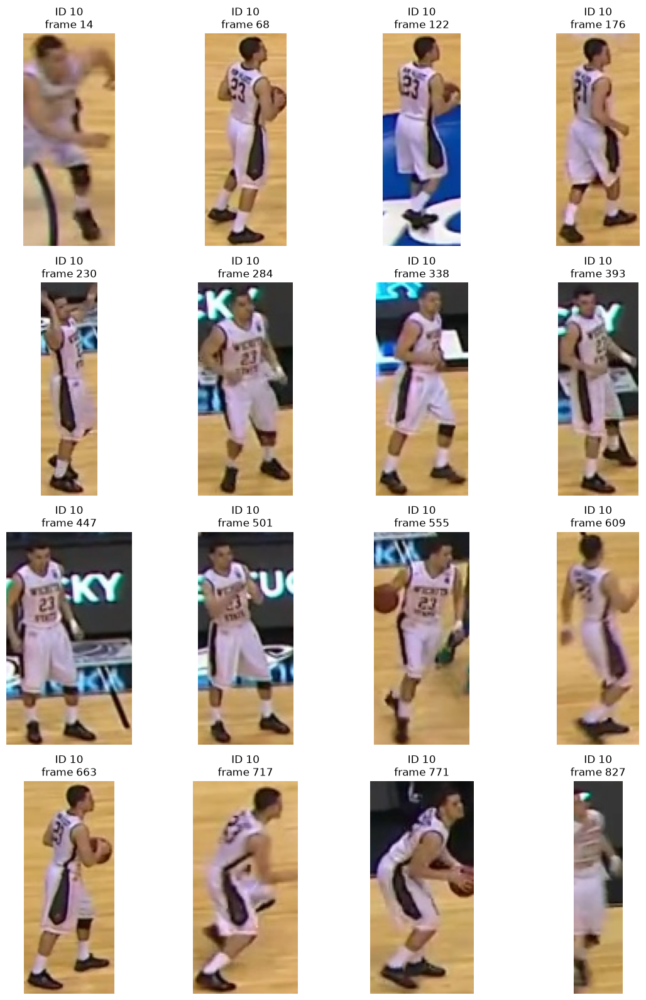

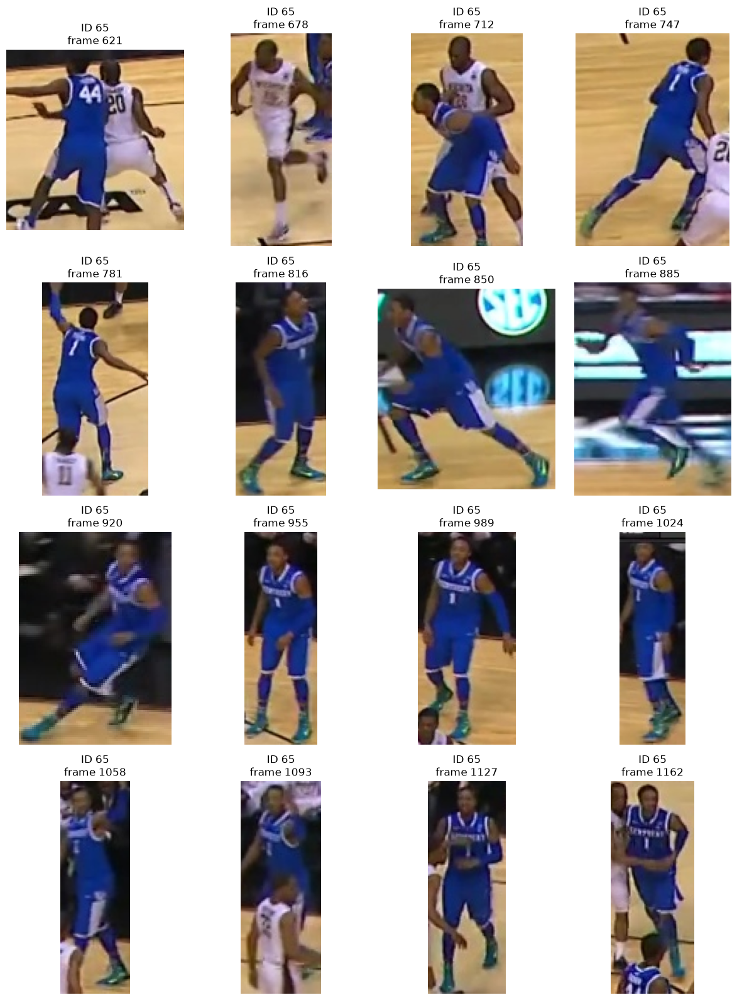

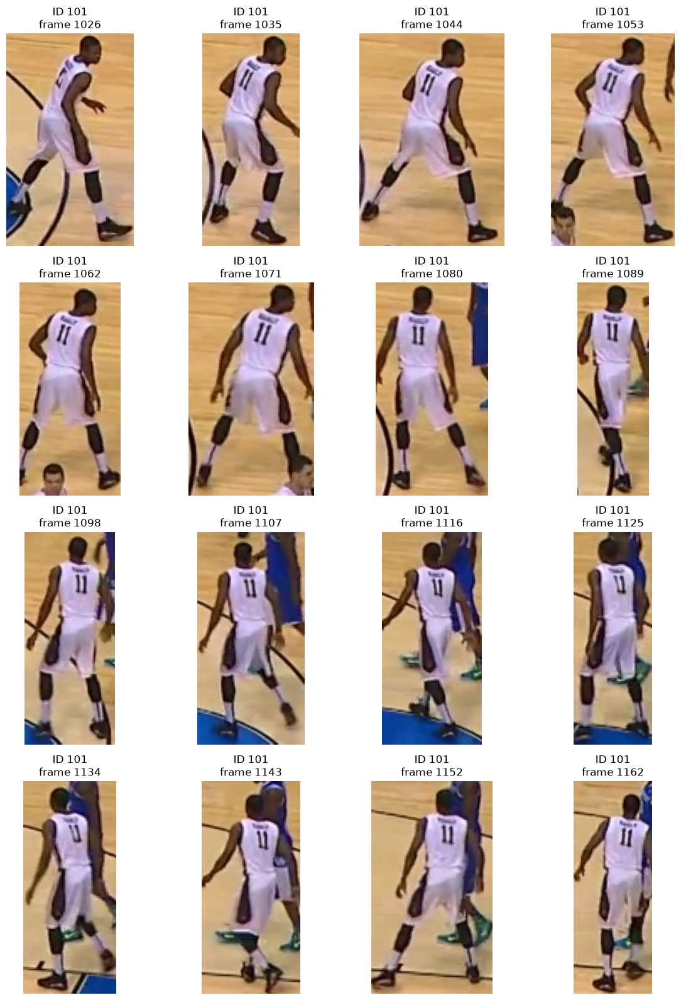

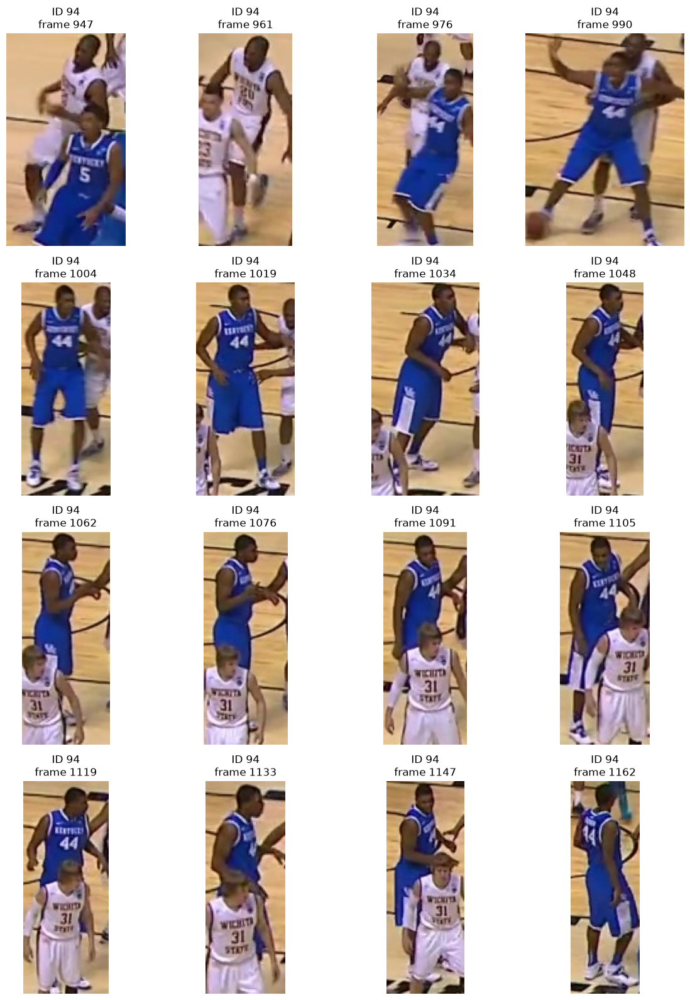

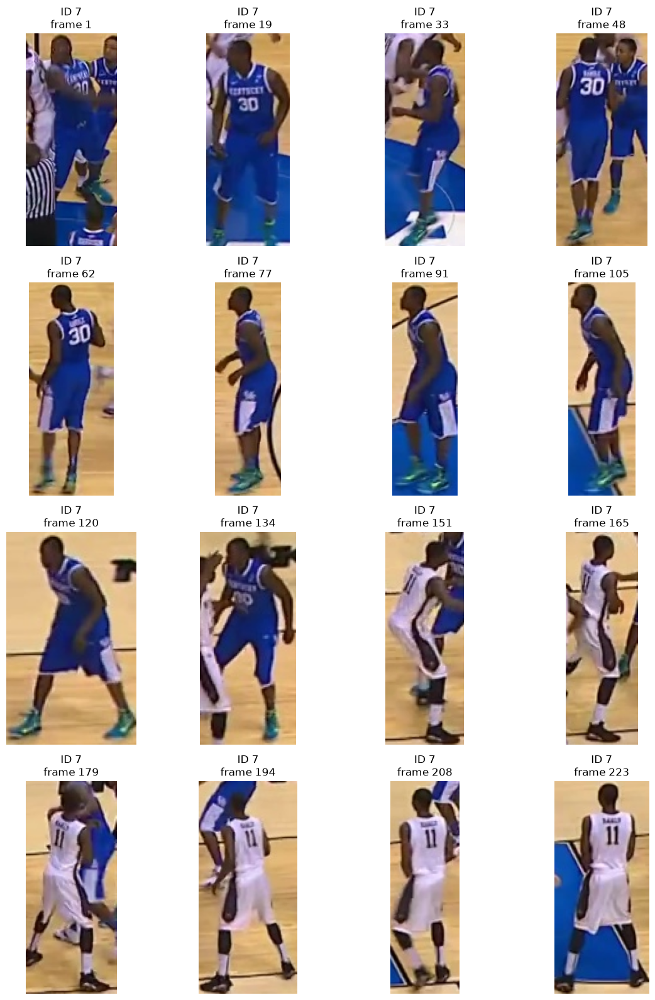

In [31]:
for track_id in track_ids_to_check[:5]:
    show_track_samples(
        track_id,
        n_samples=16
    )

## Visualizzazione cluster separati
Una galleria per cluster


CLUSTER 0
Track IDs: [0, 1, 2, 9, 10, 13, 15, 17, 18, 20, 28, 31, 32, 41, 44, 45, 46, 48, 50, 52, 79, 88, 91, 92, 101]


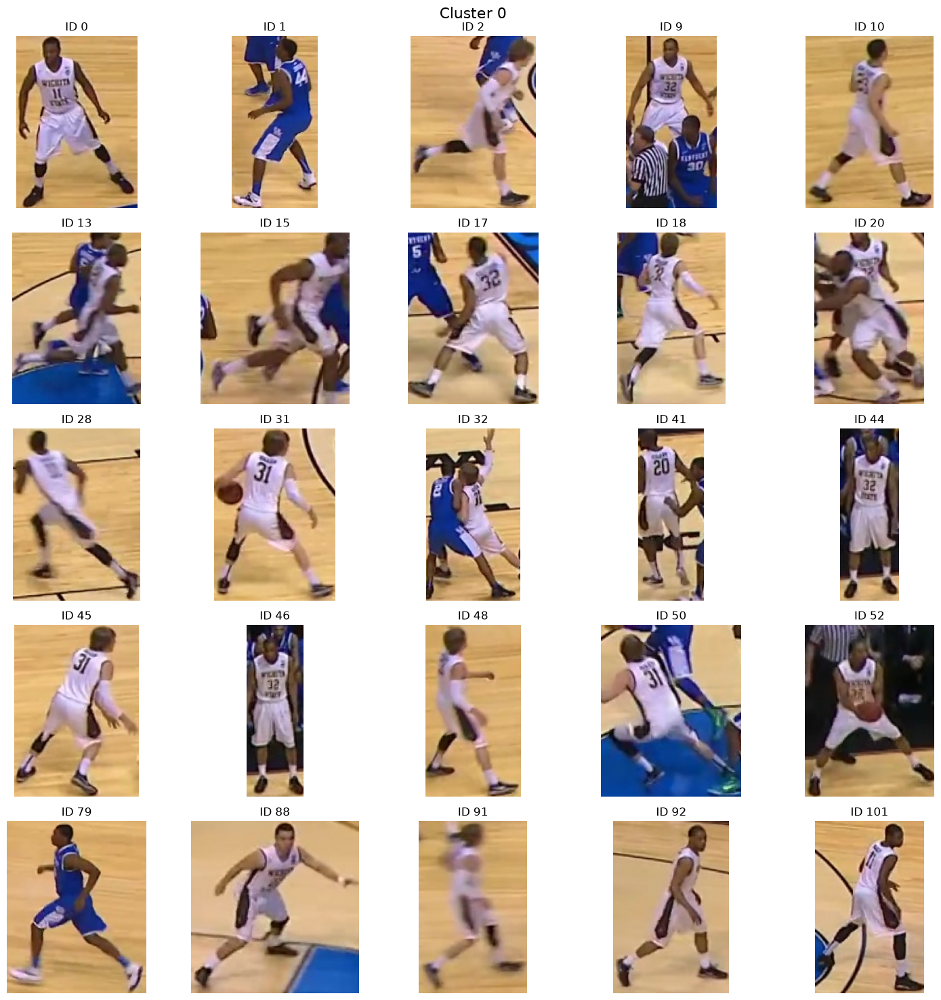


CLUSTER 1
Track IDs: [3, 4, 6, 7, 8, 12, 19, 21, 23, 24, 35, 36, 42, 43, 47, 51, 54, 55, 65, 67, 73, 78, 83, 84, 86, 94, 98, 99, 102]


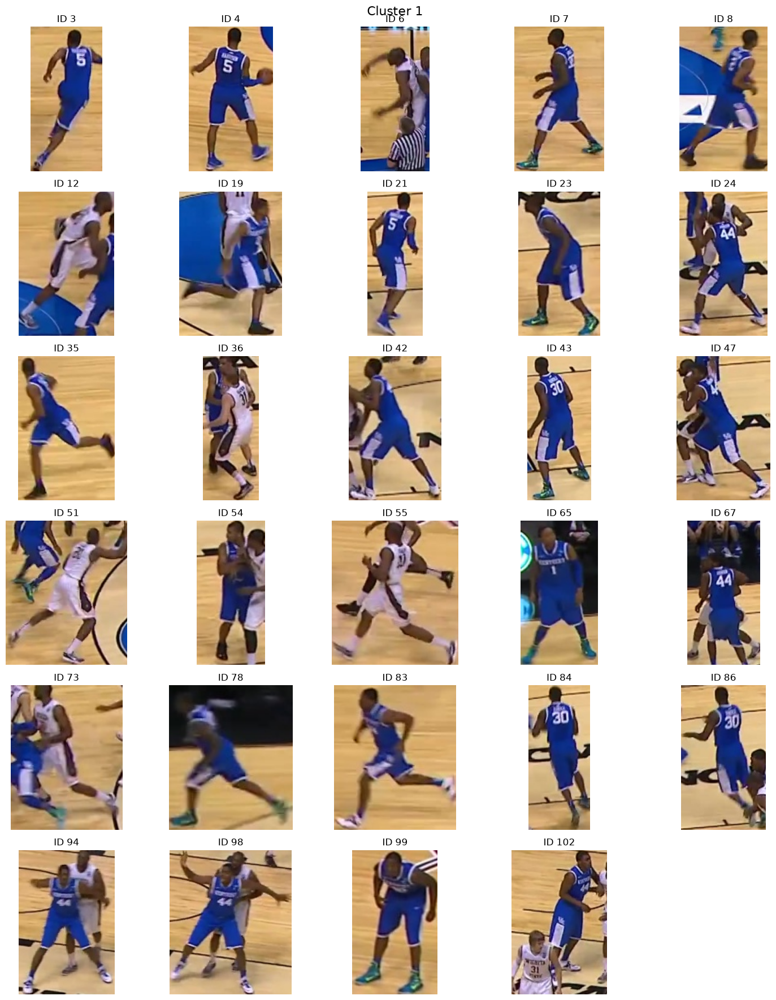

In [32]:
for cluster_id in sorted(
    cluster_table["cluster"].unique()
):

    track_ids = (
        cluster_table[
            cluster_table["cluster"]
            == cluster_id
        ]["track_id"]
        .tolist()
    )

    print(
        f"\nCLUSTER {cluster_id}"
    )

    print(
        "Track IDs:",
        track_ids
    )

    cols = 5

    rows = int(
        np.ceil(
            len(track_ids)
            / cols
        )
    )

    plt.figure(
        figsize=(
            15,
            max(
                3,
                rows * 3
            )
        )
    )

    for i, track_id in enumerate(
        track_ids
    ):

        crop = get_representative_crop(
            int(track_id)
        )

        ax = plt.subplot(
            rows,
            cols,
            i + 1
        )

        if crop is not None:

            ax.imshow(
                cv2.cvtColor(
                    crop,
                    cv2.COLOR_BGR2RGB
                )
            )

        ax.set_title(
            f"ID {int(track_id)}"
        )

        ax.axis("off")

    plt.suptitle(
        f"Cluster {cluster_id}",
        fontsize=16
    )

    plt.tight_layout()

    plt.show()

Tabella track → cluster

In [33]:
team_baseline_df = (
    player_track_features[
        ["cluster", "num_samples"]
    ]
    .reset_index()
)

team_baseline_df[
    "visual_class"
] = (
    "team_"
    + team_baseline_df[
        "cluster"
    ].astype(str)
)

display(
    team_baseline_df.sort_values(
        [
            "cluster",
            "track_id"
        ]
    )
)

,track_id,cluster,num_samples,visual_class
0,0,0,24,team_0
1,1,0,24,team_0
2,2,0,24,team_0
8,9,0,25,team_0
9,10,0,25,team_0
11,13,0,14,team_0
12,15,0,4,team_0
13,17,0,22,team_0
14,18,0,23,team_0
16,20,0,8,team_0


Aggiungo Arbitri

In [34]:
print(
    "Referee non ancora assegnati.",
    "Prima identificare manualmente i track referee dalle gallerie."
)

Referee non ancora assegnati. Prima identificare manualmente i track referee dalle gallerie.


Salva CSV

In [35]:
TEAM_CSV = (
    OUTPUT_DIR
    / "hierarchical_player_team_clusters.csv"
)

team_baseline_df.to_csv(
    TEAM_CSV,
    index=False
)

print(
    "Saved:",
    TEAM_CSV
)

print(
    "Exists:",
    TEAM_CSV.exists()
)

Saved: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking/team_classification/v_00HRwkvvjtQ_c001/hierarchical_player_team_clusters.csv
Exists: True


Integrare il cluster nel tracking originale

In [36]:
tracks_with_cluster_df = (
    tracks_df
    .merge(
        team_baseline_df[
            [
                "track_id",
                "cluster",
                "visual_class"
            ]
        ],
        on="track_id",
        how="left",
    )
)

display(
    tracks_with_cluster_df.head()
)

,frame,track_id,x1,y1,x2,y2,width,height,confidence,confirmed,cluster,visual_class
0,1,0,439.375305,266.329010,558.552917,436.577148,119.177612,170.248138,0.938461,False,0.0,team_0
1,1,1,971.564453,389.879883,1049.835327,605.411072,78.270874,215.531189,0.915086,False,0.0,team_0
2,1,2,637.455872,419.139099,764.137878,627.321350,126.682007,208.182251,0.870535,False,0.0,team_0
3,1,3,990.353394,290.022308,1052.396118,495.324768,62.042725,205.302460,0.847963,False,1.0,team_1
4,1,4,644.804443,272.780945,756.591858,430.809967,111.787415,158.029022,0.823956,False,1.0,team_1


Controllo

Salva tracking arricchito

In [37]:
ENRICHED_TRACKS_CSV = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_hierarchical_players_with_team_cluster.csv"
)

tracks_with_cluster_df.to_csv(
    ENRICHED_TRACKS_CSV,
    index=False
)

print(
    "Saved:",
    ENRICHED_TRACKS_CSV
)

print(
    "Exists:",
    ENRICHED_TRACKS_CSV.exists()
)

Saved: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking/team_classification/v_00HRwkvvjtQ_c001/v_00HRwkvvjtQ_c001_hierarchical_players_with_team_cluster.csv
Exists: True


## Result - Hierarchical Tracker Team Classification

The visual team-classification pipeline was applied to the player-only
tracks produced by the hierarchical tracker.

The pipeline includes:

1. extraction of player bounding boxes;
2. torso-region selection;
3. HSV/LAB color-feature extraction;
4. temporal aggregation of the features for each track;
5. unsupervised clustering into two visual groups;
6. analysis of the temporal consistency of the assigned cluster;
7. visualization of representative player crops;
8. saving of the team-cluster label associated with each track.

Referees were removed beforehand in Notebook 03 and are therefore not
included in this analysis.

### Interpretation

Tracks with high temporal cluster consistency provide reliable evidence
for team assignment.

Tracks whose observations alternate between the two visual clusters may
instead indicate:

- strong occlusion;
- contaminated crops;
- visual ambiguity;
- residual identity switches in the tracker.

The team-classification stage therefore also provides an additional
diagnostic tool for evaluating the temporal consistency of player tracks.